# Fitting the logarithm of air density

This notebook reads atmospheric data from a local data file and fits $\log(\rho)$ as a function of altitude. Fitting in log space gives the low-density, high-altitude data a meaningful role in the fit.

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# The two switches give four fitting options:
# fit_type = 1 or 2, each with use_errors = False or True.
use_errors = True
fit_type = 2

Define a function for fitting $\log(\rho)$. The two choices correspond to

$$\log(\rho) = a + bh$$

and

$$\log(\rho) = a + bh + ch^{3/2}.$$

In [14]:
if fit_type == 1:
    def log_fitfunction(x, a, b):
        return a + b*np.asarray(x)
elif fit_type == 2:
    def log_fitfunction(x, a, b, c):
        x = np.asarray(x)
        return a + b*x + c*np.power(x, 1.5)
else:
    raise ValueError("fit_type must be 1 or 2")

def fitfunction(x, *parameters):
    """Return density rather than log-density for plotting and residuals."""
    return np.exp(log_fitfunction(x, *parameters))

Define Python arrays to store the data.

In [15]:
altitude = []
temp = []
gravity = []
pressure = []
density = []
viscosity = []

Read data from the file and store it in the arrays above.

In [16]:
npoints = 0
with open('density.txt') as f:
    for line in f:
        npoints += 1
        data = line.split()
        altitude.append(float(data[0]))
        temp.append(float(data[1]))
        gravity.append(float(data[2]))
        pressure.append(float(data[3]))
        # The density column is tabulated in units of 0.1 kg/m^3.
        density.append(0.1*float(data[4]))
        viscosity.append(float(data[5]))

altitude = np.asarray(altitude)
density = np.asarray(density)
log_density = np.log(density)

In [17]:
# Density uncertainties, in the table's units.
density_uncertainty = [0.01,0.01,0.01,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.0001,0.0001,0.0001,0.00001,0.00001,0.000001,0.0000001,0.0000001]

# Convert them to kg/m^3 and propagate them through log(rho):
# sigma_log(rho) = sigma_rho/rho.
density_uncertainty = 0.1*np.asarray(density_uncertainty)
log_density_uncertainty = density_uncertainty/density

Text(0, 0.5, '$\\log(\\rho/[1\\;\\mathrm{kg\\,m^{-3}}])$')

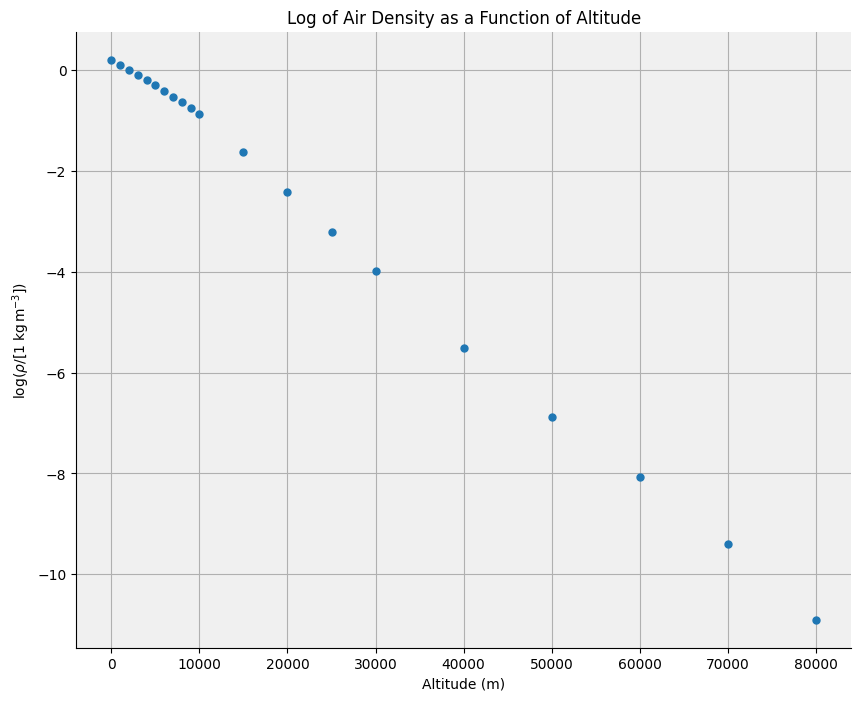

In [18]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.grid(True)
ax.set_facecolor('#F0F0F0')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

if use_errors:
    ax.errorbar(altitude, log_density, yerr=log_density_uncertainty,
                linestyle='none', marker='o', markersize=5, capsize=10)
else:
    ax.plot(altitude, log_density, linestyle='none', marker='o', markersize=5)

ax.set_title("Log of Air Density as a Function of Altitude")
ax.set_xlabel("Altitude (m)")
ax.set_ylabel(r"$\log(\rho/[1\;\mathrm{kg\,m^{-3}}])$")

Fit the log-density data with the selected function. When uncertainties are included, `curve_fit` minimizes the residuals divided by the propagated log-density uncertainties.

In [19]:
from scipy.optimize import curve_fit

if fit_type == 1:
    init_vals = [np.log(1.2), -0.0001]
elif fit_type == 2:
    init_vals = [np.log(1.2), -0.0001, -0.000001]

if use_errors:
    popt, pcov = curve_fit(log_fitfunction, altitude, log_density,
                            sigma=log_density_uncertainty, absolute_sigma=True,
                            p0=init_vals)
else:
    popt, pcov = curve_fit(log_fitfunction, altitude, log_density, p0=init_vals)

print("Fit parameters:", popt)
print("Parameter covariance matrix:\n", pcov)
print("Density amplitude exp(a) = %.6g kg/m^3" % np.exp(popt[0]))

Fit parameters: [ 3.90987052e-01 -1.45629254e-04  1.52243384e-08]
Parameter covariance matrix:
 [[ 2.78430916e-03 -2.98500708e-07  9.90293779e-10]
 [-2.98500708e-07  5.42911258e-11 -1.94850596e-13]
 [ 9.90293779e-10 -1.94850596e-13  7.16676812e-16]]
Density amplitude exp(a) = 1.47844 kg/m^3


Evaluate goodness of fit in the same log space used for fitting. For a weighted fit the statistic is $\chi^2$; without uncertainties it is the unweighted sum of squared log residuals.

In [20]:
log_yfit = log_fitfunction(altitude, *popt)
yfit = np.exp(log_yfit)
dof = npoints - len(popt)

if use_errors:
    chi2 = np.sum(((log_density - log_yfit)/log_density_uncertainty)**2)
    print("Chi^2 / dof = %.3E / %d" % (chi2, dof))
else:
    sum_squared_log_residuals = np.sum((log_density - log_yfit)**2)
    print("Sum of squared log residuals / dof = %.3E / %d" %
          (sum_squared_log_residuals, dof))

Sum of squared log residuals / dof = 2.601E-01 / 17


Draw the density data and the fitted curve on a logarithmic density axis.

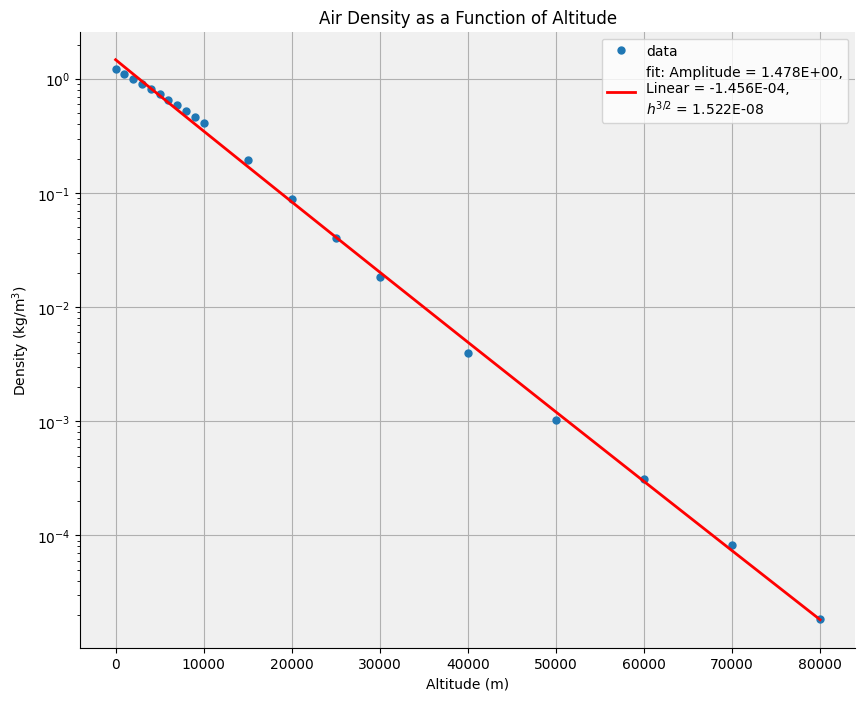

In [21]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.grid(True)
ax.set_facecolor('#F0F0F0')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

if use_errors:
    ax.errorbar(altitude, density, yerr=density_uncertainty,
                linestyle='none', marker='o', markersize=5, capsize=10,
                label='data')
else:
    ax.plot(altitude, density, linestyle='none', marker='o', markersize=5,
            label='data')

if fit_type == 1:
    fit_label = ('fit: Amplitude = %.3E,\nLinear = %.3E' %
                 (np.exp(popt[0]), popt[1]))
else:
    fit_label = ('fit: Amplitude = %.3E,\nLinear = %.3E,\n$h^{3/2}$ = %.3E' %
                 (np.exp(popt[0]), popt[1], popt[2]))

ax.plot(altitude, yfit, color='r', linewidth=2, label=fit_label)
ax.set_title("Air Density as a Function of Altitude")
ax.set_xlabel("Altitude (m)")
ax.set_ylabel(r"Density ($\mathrm{kg/m^3}$)")
ax.set_yscale('log')
ax.legend()

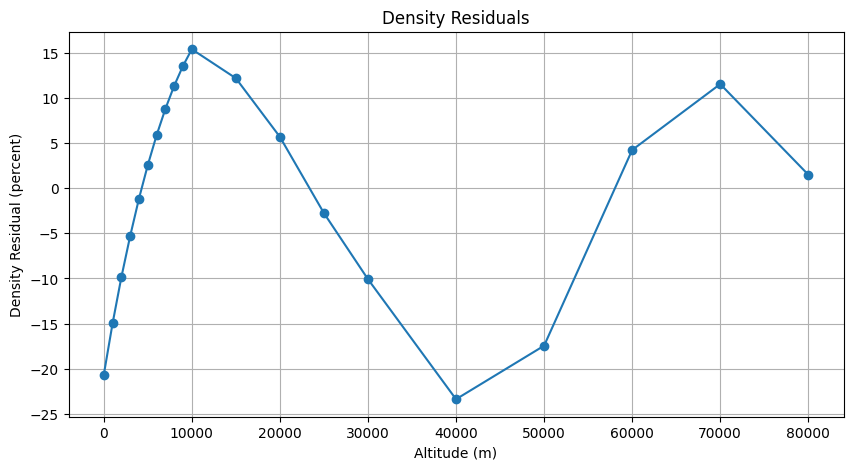

In [22]:
plt.figure(figsize=(10, 5))
plt.title("Density Residuals")
plt.xlabel('Altitude (m)')
plt.ylabel('Density Residual (percent)')
plt.grid(True)
plt.plot(altitude, (density - yfit)/density*100, 'o-')

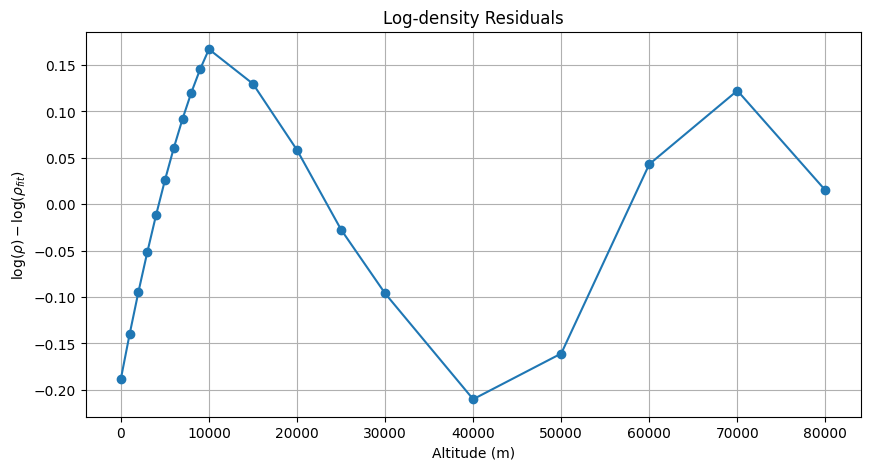

In [23]:
plt.figure(figsize=(10, 5))
plt.title("Log-density Residuals")
plt.xlabel('Altitude (m)')
plt.ylabel(r"$\log(\rho)-\log(\rho_{fit})$")
plt.grid(True)
plt.plot(altitude, log_density - log_yfit, 'o-')

### Conclusions

Fitting $\log(\rho)$ changes the question being asked by the least-squares procedure: fractional differences across the full altitude range matter, rather than absolute density differences being dominated by the lowest-altitude points. The two model choices and the optional propagated uncertainties allow the four approaches to be compared directly.